In [10]:
pip install scienceplots

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import accumulate, product, chain
import torch

### Primary vertex cubelet dimensions & Optics $PbWO_4$ parameters 

In [3]:
nCells = (10,10,10)
cellSize = (3,3,12) # mm
n = 2.2 # PWO refractive index
c0 = 299.792458/n # mm/ns - phase velocity
c = c0/n # mm/ns - group velocity

### Solid Angles subtended by a plate

In [4]:
"""Compute solid angle underlying a rectangle [a*b] from the point perpendicular to the rectangle at distance d""" 

def onAxis_SolidAngle(a, b, d):
    alpha = a/(2*d)
    beta  = b/(2*d)
    return 4*np.arcsin(alpha*beta/np.sqrt((1+alpha**2)*(1+beta**2)))

In [5]:
"""Generalisation of previous formula when the point is not perpendicular to the rectangle:
    A, B : point coordinates
    a, b : rectangle dimensions
    d    : distance between point and rectangle plane
"""

def offAxis_SolidAngle(A, B, a, b, d):
    sign_A = np.sign(A)
    A *= sign_A
    sign_B = np.sign(B)
    B *= sign_B

    o1 = onAxis_SolidAngle(2*(a+sign_A*A), 2*(b+sign_B*B), d)
    o2 = onAxis_SolidAngle(2*A,            2*(b+sign_B*B), d)
    o3 = onAxis_SolidAngle(2*(a+sign_A*A), 2*B,            d)
    o4 = onAxis_SolidAngle(2*A,            2*B,            d)

    return (o1 - sign_A*o2 - sign_B*o3 + sign_A*sign_B*o4)/4

### Combinations Analysis for fixed amount $n$ of reflections

In [6]:
def generate_tuples_two_integers(n):
    """
    Generate all tuples of two integers (a, b) such that
    the sum of their absolute values equals n.

    Parameters:
        n (int): Target sum of absolute values.

    Returns:
        list of tuples: List of (a, b) satisfying the condition.
    """
    result = []
    for a in range(-n, n + 1):  # Iterate over possible values of a
        b_abs = n - abs(a)      # Compute the absolute value of b
        if b_abs >= 0:          # Ensure b_abs is non-negative
            # Add both positive and negative combinations of b
            result.append((a, b_abs))
            if b_abs != 0:  # Avoid duplicates when b_abs is 0
                result.append((a, -b_abs))
    return result

def all_reflections(n):
    """
    Generate all possible reflection paths such that
    the total amount of reflections equals n. A reflection 
    path is a (x, y, z) tuple where each coordinate is a
    (positive or negative) integer which signifies the amount
    of times a ray reflected in that direction.
    Positive values mean that the ray first reflected in the face
    in the positive direction of the axis and viceversa.

    Parameters:
        n (int): Target number of reflections.

    Returns:
        list of tuples: List of (x,y,z) satisfying the condition.
    """
    paths_horizontal = generate_tuples_two_integers(n)
    paths_vertical = generate_tuples_two_integers(n-1)
    paths = [(x, 0, z) for x, z in paths_horizontal] + [(x, -1, z) for x, z in paths_vertical]
    return paths
    

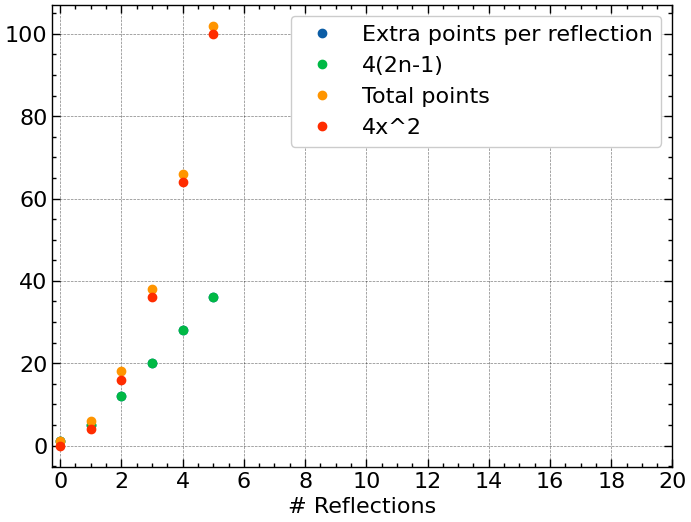

In [7]:
import scienceplots
plt.style.use(['science', 'notebook', 'grid'])

x = np.arange(0,6)
n_extra_point = [len(all_reflections(n)) for n in x]
total_point = list(accumulate(n_extra_point))
def test(N):
    if N==0:
        return 1
    elif N==1:
        return 5
    elif N > 1:
        return 4*(2*N-1)
r = [test(n) for n in x]
plt.plot(x, n_extra_point, 'o', label="Extra points per reflection")
plt.plot(x, r, 'o', label='4(2n-1)')
plt.plot(x, total_point, 'o', label='Total points')
plt.plot(x, 4*x**2, 'o',label='4x^2')
plt.legend()
plt.xlabel("# Reflections")
plt.xticks(np.arange(0, 22, 2))
plt.show()

In [8]:
# Example of usage
"""Computing dimension of all possible configuration for a given fixed number of reflections n"""

num_refl = int(input("Enter the number of reflections: "))
print(all_reflections(num_refl))
len(all_reflections(num_refl))

[(-4, 0, 0), (-3, 0, 1), (-3, 0, -1), (-2, 0, 2), (-2, 0, -2), (-1, 0, 3), (-1, 0, -3), (0, 0, 4), (0, 0, -4), (1, 0, 3), (1, 0, -3), (2, 0, 2), (2, 0, -2), (3, 0, 1), (3, 0, -1), (4, 0, 0), (-3, -1, 0), (-2, -1, 1), (-2, -1, -1), (-1, -1, 2), (-1, -1, -2), (0, -1, 3), (0, -1, -3), (1, -1, 2), (1, -1, -2), (2, -1, 1), (2, -1, -1), (3, -1, 0)]


28

In [9]:
n_extra_point

[1, 5, 12, 20, 28, 36]

### Reflection algorithm: new coordinates of the mirrored energy deposit location

In [12]:
def reflect(old_coordinates, reflection, nCells=nCells):

    def reflect_onedim(old_coordinate, reflection, nCell):
        nc = old_coordinate # new coordinate
        if reflection != 0:
            sign = np.sign(reflection)
            reflection *= sign 
            partial_shift = reflection%2 # if reflection is odd, the ray is shifted 
            if partial_shift: # odd n. of reflections
                if sign>0: 
                    nc = 2*nCell-1-old_coordinate 
                else:
                    nc = -1*old_coordinate-1
            whole_shifts = reflection//2 # quotient without rest
            nc += whole_shifts*sign*2*nCell
        return int(nc) # explicit conversion to int
    
    nc = [reflect_onedim(oc, r, n) for oc, r, n in zip(old_coordinates, reflection, nCells)]

    return nc

In [13]:
# Example of usage

test_oc = [2, 0, 0]
test_reflections = [2, 0, 1]
test_nc = reflect(test_oc, test_reflections, nCells)
print(test_nc)

[22, 0, 19]


### Find interaction cell-sensor Distance and Propagation Time

In [14]:
print("Height x: ", cellSize[0], "mm")
print("#Cells_x: ", nCells[0])
print("---------")
print("Width y: ", cellSize[1], "mm")
print("#Cells_y: ", nCells[1])
print("---------")
print("Lenght z: ", cellSize[2], "mm")
print("#Cells_z: ", nCells[2])

Height x:  3 mm
#Cells_x:  10
---------
Width y:  3 mm
#Cells_y:  10
---------
Lenght z:  12 mm
#Cells_z:  10


In [15]:
def find_distances(edep_idx, sensor_idx, cellSize=cellSize, nCells=nCells):
    shift_x = abs(edep_idx[0] - sensor_idx[0])
    if shift_x == 0:
        A = -0.5*cellSize[0]
    else:
        A = cellSize[0]*(shift_x-1+0.5)
        
    d = cellSize[1]*(nCells[1]-1-edep_idx[1]+0.5) # edep-sensor vertical distance corresponding to ∆𝑦
       
    shift_z = abs(edep_idx[2] - sensor_idx[1])      # sensor_idx is 2-dimensional, sensors are placed in a 2D grid
    if shift_z == 0:
        B = -0.5*cellSize[2]
    else:
        B = cellSize[2]*(shift_z-1+0.5)
    
    # flight time
    t = np.sqrt(d**2 + (shift_x*cellSize[0])**2 + (shift_z*cellSize[2])**2)/c 

    return A, B, d, t

In [16]:
# Example of usage
test_edep_idx = [2, 3, 4]
test_sensor_idx = [5, 7]
A, B, d, t = find_distances(test_edep_idx, test_sensor_idx)
print(f"A: {A}, B: {B}, d: {d}, t: {t}")

A: 7.5, B: 30.0, d: 19.5, t: 0.6767705232038908


### Bundle-up it all

In [17]:
"""For each possible reflection combination given fixed N (#reflections), get the 3-tuple new coordinates of the N spots
    where the ray bounced, lengths of the N paths leading to the final spot (where the sensor is located) and the solid 
    angle and flight time associated to each path"""
    

def compute_angles(edep_idx, sensor_idx, N, cellSize=cellSize):
    reflections = [all_reflections(n) for n in range(N+1)]
    new_coordinates = [[reflect(edep_idx, r) for r in ref] for ref in reflections]
    lengths = [[find_distances(edep, sensor_idx) for edep in n] for n in new_coordinates]
    omegas = [[(offAxis_SolidAngle(A, B, cellSize[0], cellSize[2], d), t) for A, B, d, t in l] for l in lengths]
    return omegas

In [18]:
"""Idem, but with reflection e**n and attenuation exp**(-mu*x) coefficients"""

ref_coeff = 0.98 # %
att_coeff = 0.004 # mm^-1 --> means lambda_att = 25 cm



def compute_angles_ref_att(edep_idx, sensor_idx, N, cellSize=cellSize, ref_coeff=ref_coeff, att_coeff=att_coeff):
    reflections = [all_reflections(n) for n in range(N+1)]
    new_coordinates = [[reflect(edep_idx, r) for r in ref] for ref in reflections]
    lengths = [[find_distances(edep, sensor_idx) for edep in n] for n in new_coordinates]
    
    #(f"new_coordinates: {new_coordinates}")  
    #print(f"lengths: {lengths}")  

    """
    for l in lengths:
        for x,y,z,d in l:
            if d is not None:
                print(f"factor: {np.exp(-att_coeff*d)}")
            else:
                print("Errore: distanza None")
    """
    
    omegas = [[ (offAxis_SolidAngle(A, B, cellSize[0], cellSize[2], d) * np.exp(-att_coeff*d) * (ref_coeff**n), t) for A, B, d, t in l] for n, l in enumerate(lengths)] 
    return omegas

In [19]:
# Example of usage
compute_angles_ref_att(test_edep_idx, test_sensor_idx, 5, cellSize, ref_coeff, att_coeff)

[[(np.float64(0.009055782263368707), np.float64(0.6767705232038908))],
 [(np.float64(0.006043623171076106), np.float64(0.766183784796743)),
  (np.float64(0.0006730613118039843), np.float64(1.5881833512546242)),
  (np.float64(0.00020686277888682948), np.float64(2.350522537402757)),
  (np.float64(0.003956675050482469), np.float64(0.8801715498627)),
  (np.float64(0.007379148677378677), np.float64(0.8868094383838039))],
 [(np.float64(0.001208016839183589), np.float64(1.2953133652681361)),
  (np.float64(0.0006116032708206409), np.float64(1.6282953074335633)),
  (np.float64(0.00019579462577442254), np.float64(2.377808959913746)),
  (np.float64(7.237107062075741e-05), np.float64(3.3116797530563575)),
  (np.float64(2.942070760442621e-05), np.float64(4.469352560686079)),
  (np.float64(0.0005514925918084974), np.float64(1.6849361926531248)),
  (np.float64(0.0001863957560460663), np.float64(2.4169484510324866)),
  (np.float64(0.0022352697335786464), np.float64(1.0558615529204232)),
  (np.float64(

In [20]:
def compute_angles_ref_att_2(edep_idx, sensor_idx, N, cellSize=cellSize, ref_coeff=ref_coeff, att_coeff=att_coeff):
    reflections = [all_reflections(n) for n in range(N+1)]
    new_coordinates = [[reflect(edep_idx, r) for r in ref] for ref in reflections]

    omegas = []
    for n, ref_group in enumerate(new_coordinates):  
        for edep in ref_group:
            lengths = find_distances(edep, sensor_idx)

            # Se lengths è una tupla, la trasformiamo in una lista di tuple
            if isinstance(lengths, tuple):  
                lengths = [lengths]

            # Calcolo omega per ogni entry di lengths
            omegas.extend(
                (offAxis_SolidAngle(A, B, cellSize[0], cellSize[2], d) * np.exp(-att_coeff*d) * (ref_coeff**n), d)
                for A, B, d, t in lengths
            )
    
    return omegas

#### Shape di omegas

In [21]:
def get_nested_shape(data):
    """
    Calcola la 'shape' di una lista annidata.
    Restituisce una tupla con le lunghezze dei livelli e una lista con le lunghezze variabili.
    """
    if not isinstance(data, list):
        return ()
    
    outer_len = len(data)
    inner_lengths = [len(sublist) for sublist in data if isinstance(sublist, list)]
    
    if not inner_lengths:
        return (outer_len,)
    
    # Verifica il livello più interno (tuple)
    tuple_len = None
    for sublist in data:
        if sublist and isinstance(sublist, list):
            for item in sublist:
                if isinstance(item, tuple):
                    tuple_len = len(item)
                    break
            if tuple_len is not None:
                break
    
    if tuple_len is not None:
        return (outer_len, inner_lengths, tuple_len)
    return (outer_len, inner_lengths)

# Test
test_N = 2
test_edep_idx = [2, 3, 4]
test_sensor_idx = [5, 6, 7]
test_omegas = compute_angles(test_edep_idx, test_sensor_idx, test_N)
test_shape = get_nested_shape(test_omegas)
print("Shape di omegas:", shape)
print("Numero max di riflessioni considerate: ", shape[0])
print("Combinazioni per n=0 fino a n=N: ", shape[1])
print("Dimensione tupla interna con angolo, distanza e tempo: ", shape[2])

NameError: name 'shape' is not defined

### NEW: Linear attenuation coefficient: absorbtion of the detector material $PbWO_4$

In [22]:
# from XCOM NIST database: https://physics.nist.gov/cgi-bin/Xcom/xcom2?Method=Elem&Output2=Hand
# photon energy selected: 100 GeV
ac_Pb = 0.1197 # cm^2/g
ac_W = 0.1131 # cm^2/g
ac_O = 0.0224 # cm^2/g

# Attenuation coefficient for PbWO4 (mu/rho) in cm^2/g
mass_att_coefficient_PbWO4 = (0.455 * ac_Pb) + (0.404 * ac_W) + (0.141 * ac_O)
density_PbWO4 = 8.28 # g/cm^3
att_coefficient_PbWO4 = mass_att_coefficient_PbWO4 * density_PbWO4
att_length_PbWO4 = 1/att_coefficient_PbWO4

# Actually the energy, since E_gamma is proportional to N_gamma,
# where N_gamma is the number of photons: they follow the same exponential law
init_intensity = 100

# Lambert-Beer law
def intensity(init_intensity, distance, att_coefficient):
    return init_intensity*np.exp(-att_coefficient*distance)

def compute_intensities(edep_idx, sensor_idx, N, cellSize=cellSize, att_coefficient=att_coefficient_PbWO4):
    omegas = compute_angles(edep_idx, sensor_idx, N, cellSize)
    intensities = [[intensity(init_intensity, d, att_coefficient) for _, d, _ in o] for o in omegas]
    return intensities    

print(f"Attenuation length: {att_length_PbWO4:.4f} cm")
print(f"Attenuation coefficient: {att_coefficient_PbWO4:.4f} cm^-1")

Attenuation length: 1.1690 cm
Attenuation coefficient: 0.8554 cm^-1


In [23]:
edep_idx

NameError: name 'edep_idx' is not defined

### NEW: Reflection coefficient due to walls collisions

In [24]:
# constant coefficient: between 0.95 and 0.98
ref_coeff_const = 0.98

# angle-dependant coefficient: the long way
n1 = 2.2 # PbWO4
n2 = 1.5 # SiO2
 
def get_theta_inc(edep_idx, sensor_idx, cellSize=cellSize):
    x_coord, z_coord, d, flight_time = find_distances(edep_idx, sensor_idx)
    delta_y = cellSize[1]*(edep_idx[1] - sensor_idx[1])
    
    return np.arccos(delta_y/d)
 
def one_fresnel_reflection(theta_inc, n1=n1, n2=n2): 
    addA = n1 * np.cos(theta_inc)
    addB = n2 * np.sqrt(1 - (n1/n2 * np.sin(theta_inc))**2)
    ref_coeff_s = (abs((addA-addB)/(addA+addB)))**2
    addC = n1 * np.sqrt(1 - (n1/n2 * np.sin(theta_inc))**2)
    addD = n2 * np.cos(theta_inc)
    ref_coeff_p = (abs((addC-addD)/(addC+addD)))**2
    ref_coeff_total = (ref_coeff_s + ref_coeff_p)/2
    
    return ref_coeff_total

# loop

### Attempt to resolve for all angles with loops (slower way, don't run)

In [106]:
def compute_matrices(N):

    reflections = [all_reflections(n) for n in range(N+1)]

    new_coordinates = [[[[[reflect((x, y, z), r) for x in range(nCells[0])] # cell idz x
                                                 for y in range(nCells[1])] # cell idx y
                                                 for z in range(nCells[2])] # cell idx z
                                                 for r in ref]              # possible reflections fixing n
                                                 for ref in reflections]    # all different ns
        
    lengths = [[[[[[[find_distances(edep_x, (s_x, s_z)) for s_x in range(nCells[0])]   # sensor idx x
                                                        for s_z in range(nCells[2])]   # sensor idx z
                                                        for edep_x in edep_y]          # cell idx x
                                                        for edep_y in edep_z]          # cell idx y
                                                        for edep_z in edep_ref]        # cell idx z
                                                        for edep_ref in edep_n]        # possible reflections fixing n
                                                        for edep_n in new_coordinates] # all different ns

    omegas = [[[[[[[[offAxis_SolidAngle(A, B, cellSize[0], cellSize[2], d) for A, B, d in l] for l in lengths]
    times = []

    return omegas, times

SyntaxError: invalid syntax (1975263300.py, line 20)

In [ ]:
N = 5
reflections = [all_reflections(n) for n in range(N+1)]
new_coordinates = [[[[[reflect((x, y, z), r) for x in range(nCells[0])]
                                                     for y in range(nCells[1])]
                                                      for z in range(nCells[2])]
                                                      for r in ref]
                                                      for ref in reflections]

In [ ]:
lengths = [[[[[[[find_distances(edep_x, (s_x, s_z)) for s_x in range(nCells[0])]
                                                 for s_z in range(nCells[2])]
                                                 for edep_x in edep_y]
                                                 for edep_y in edep_z]
                                                 for edep_z in edep_ref]
                                                 for edep_ref in edep_n]
                                                 for edep_n in new_coordinates]

: 

### Trial: Analyzing Angle Coverage (N=5) and other checks (don't run)

In [ ]:
import sys
def total_size(obj, seen=None):
    """Recursively find the size of an object, including referenced objects."""
    if seen is None:
        seen = set()

    obj_id = id(obj)
    if obj_id in seen:
        return 0
    seen.add(obj_id)

    size = sys.getsizeof(obj)
    if isinstance(obj, dict):
        size += sum(total_size(k, seen) + total_size(v, seen) for k, v in obj.items())
    elif isinstance(obj, (list, tuple, set)):
        size += sum(total_size(i, seen) for i in obj)

    return size
total_size(lengths)

NameError: name 'lengths' is not defined

In [ ]:
a = [[10*y+x for x in range(3)] for y in range(5)]
print(a)
print(a[0][2])

[[0, 1, 2], [10, 11, 12], [20, 21, 22], [30, 31, 32], [40, 41, 42]]
2


In [ ]:
a = torch.rand(3,5)
print(a)
print(a[0][2])

tensor([[0.7976, 0.0923, 0.9855, 0.7538, 0.1337],
        [0.8559, 0.8130, 0.7755, 0.7794, 0.6104],
        [0.6831, 0.5678, 0.9454, 0.9454, 0.5436]])
tensor(0.9855)


In [ ]:
o = torch.zeros(*nCells, *(nCells[0,2]))

In [ ]:
o.size()

In [ ]:
N = 6
edep_idx = (0,2,4)
reflections = [all_reflections(n) for n in range(N+1)]
new_coordinates = [[reflect(edep_idx, r) for r in ref] for ref in reflections]

In [ ]:
from itertools import chain
a = list(chain.from_iterable(reflections))
len(a)

146

In [ ]:
for n in reflections:
    print(len(n))
    print(type(n[0]))

1
<class 'tuple'>
5
<class 'tuple'>
12
<class 'tuple'>
20
<class 'tuple'>
28
<class 'tuple'>
36
<class 'tuple'>
44
<class 'tuple'>


In [ ]:
N = 5
edep_idx = (0,0,0)
sensor_idx = (9,9)
omegas = compute_angles(edep_idx, sensor_idx, N)

NameError: name 'compute_angles' is not defined

In [ ]:
omega_sum = [np.sum(x) for x in omegas]
omega_cum = list(accumulate(omega_sum))

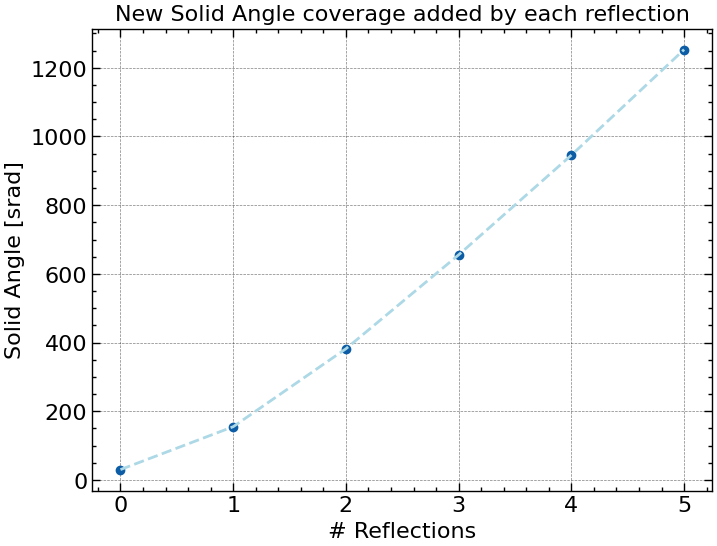

In [ ]:
x = 6
plt.title("New Solid Angle coverage added by each reflection")
plt.ylabel("Solid Angle [srad]")
plt.xlabel("# Reflections")
plt.plot(np.arange(x), omega_sum[:x], 'o')
plt.plot(np.arange(x), omega_sum[:x], '--', color="lightblue")

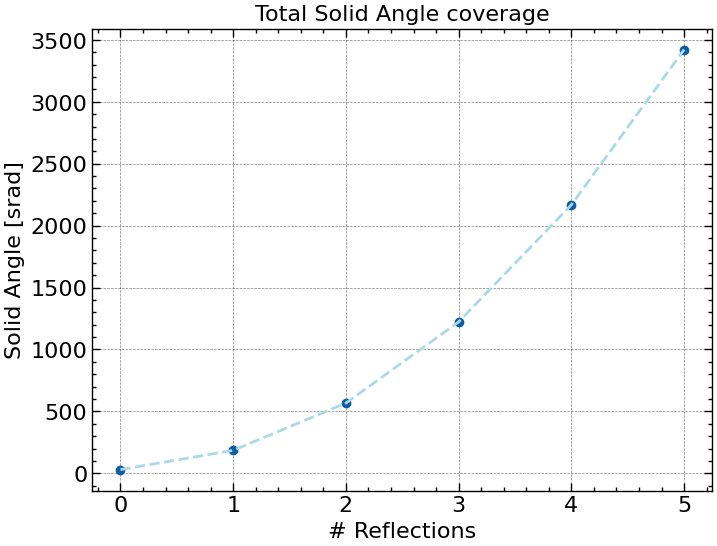

In [ ]:
x = 6
plt.title("Total Solid Angle coverage")
plt.ylabel("Solid Angle [srad]")
plt.xlabel("# Reflections")
plt.plot(np.arange(x), omega_cum[:x], 'o')
plt.plot(np.arange(x), omega_cum[:x], '--', color="lightblue")

In [ ]:
a = [0,2,3,4]
for i, n in enumerate(a):
    print(i, n)

0 0
1 2
2 3
3 4


In [ ]:
Blue (#1f77b4)
Orange (#ff7f0e)
Green (#2ca02c)
Red (#d62728)
Purple (#9467bd)
Brown (#8c564b)
Pink (#e377c2)
Gray (#7f7f7f)
Olive (#bcbd22)
Cyan (#17becf)

In [ ]:
N = 5
o = compute_angles((5,5,5), (1, 1), N)
a = list(chain.from_iterable(o))
a

[(np.float64(0.0036862132380456325), 13.5, np.float64(0.8279863427401087)),
 (np.float64(0.0031242893368802482), 13.5, np.float64(0.873483219282899)),
 (np.float64(0.0001258391295031469), 13.5, np.float64(2.5353680119250646)),
 (np.float64(0.000773218769008821), 13.5, np.float64(1.3871359678989517)),
 (np.float64(0.0019325151719948863), 13.5, np.float64(1.0219928972464463)),
 (np.float64(0.005377805804360591), 46.5, np.float64(1.0961926782255553)),
 (np.float64(0.0014740956822993923), 13.5, np.float64(1.1173873451363576)),
 (np.float64(0.00012359063147393545), 13.5, np.float64(2.5505886588192794)),
 (np.float64(0.0007282439174698396), 13.5, np.float64(1.4147642008630403)),
 (np.float64(2.0242744684484393e-05), 13.5, np.float64(4.658752008340393)),
 (np.float64(6.789091504166844e-05), 13.5, np.float64(3.113430729705083)),
 (np.float64(0.00011595339540959593), 13.5, np.float64(2.6051869518617847)),
 (np.float64(0.0005965297260510649), 13.5, np.float64(1.5109779256153961)),
 (np.float64(0

In [ ]:
# Generate all possible combinations
combinations = list(product(range(10), range(10), range(10)))
combinations

[(0, 0, 0),
 (0, 0, 1),
 (0, 0, 2),
 (0, 0, 3),
 (0, 0, 4),
 (0, 0, 5),
 (0, 0, 6),
 (0, 0, 7),
 (0, 0, 8),
 (0, 0, 9),
 (0, 1, 0),
 (0, 1, 1),
 (0, 1, 2),
 (0, 1, 3),
 (0, 1, 4),
 (0, 1, 5),
 (0, 1, 6),
 (0, 1, 7),
 (0, 1, 8),
 (0, 1, 9),
 (0, 2, 0),
 (0, 2, 1),
 (0, 2, 2),
 (0, 2, 3),
 (0, 2, 4),
 (0, 2, 5),
 (0, 2, 6),
 (0, 2, 7),
 (0, 2, 8),
 (0, 2, 9),
 (0, 3, 0),
 (0, 3, 1),
 (0, 3, 2),
 (0, 3, 3),
 (0, 3, 4),
 (0, 3, 5),
 (0, 3, 6),
 (0, 3, 7),
 (0, 3, 8),
 (0, 3, 9),
 (0, 4, 0),
 (0, 4, 1),
 (0, 4, 2),
 (0, 4, 3),
 (0, 4, 4),
 (0, 4, 5),
 (0, 4, 6),
 (0, 4, 7),
 (0, 4, 8),
 (0, 4, 9),
 (0, 5, 0),
 (0, 5, 1),
 (0, 5, 2),
 (0, 5, 3),
 (0, 5, 4),
 (0, 5, 5),
 (0, 5, 6),
 (0, 5, 7),
 (0, 5, 8),
 (0, 5, 9),
 (0, 6, 0),
 (0, 6, 1),
 (0, 6, 2),
 (0, 6, 3),
 (0, 6, 4),
 (0, 6, 5),
 (0, 6, 6),
 (0, 6, 7),
 (0, 6, 8),
 (0, 6, 9),
 (0, 7, 0),
 (0, 7, 1),
 (0, 7, 2),
 (0, 7, 3),
 (0, 7, 4),
 (0, 7, 5),
 (0, 7, 6),
 (0, 7, 7),
 (0, 7, 8),
 (0, 7, 9),
 (0, 8, 0),
 (0, 8, 1),
 (0, 8, 2),
 (0,

In [ ]:
L = sum([len(all_reflections(n)) for n in range(N+1)])
L

102

### Run the simulation HERE 

In [ ]:
# estimated time: ca. 6'30" at fixed N=5

N = 5
L = sum([len(all_reflections(n)) for n in range(N+1)])
ot = torch.zeros(size=(nCells[0], nCells[1], nCells[2], L, nCells[0], nCells[2], 2))
edep_idx = list(product(range(nCells[0]), range(nCells[1]), range(nCells[2])))
for i, edep in enumerate(edep_idx):
    for x_i in range(nCells[0]):
        for z_i in range(nCells[2]):
            omegas = compute_angles_ref_att(edep, (x_i, z_i), N) # edit here
            omegas = torch.tensor(list(chain.from_iterable(omegas)))
            ot[edep[0], edep[1], edep[2], :, x_i, z_i, 0] = omegas[:, 0]
            ot[edep[0], edep[1], edep[2], :, x_i, z_i, 1] = omegas[:, 1]

### Save results to feed genPhotons.cpp

In [29]:
# 1. Converts pytorch tensor to numpy array, 
# 2. Prints output in a binary file
# 3. Writes output shape in a text file

ot.numpy().astype(np.float32).tofile("emission_matrix_mufix.bin")
with open("shape.txt", "w") as f:
    f.write(" ".join(map(str, ot.shape)))

### Other checks

In [30]:
# check type

ot.dtype

torch.float32

In [33]:
shape = ot.shape
edep = (0,0,0)
sensor = (0,0)
n = 0
i = 0
o = compute_angles(edep, sensor, N)
ot_flat =np.fromfile("emission_matrix.bin", dtype=np.float32)
l = [len(o[i]) for i in range(n)]
print(sum(l)+i)
print(o[n][i])
print(ot[edep[0], edep[1], edep[2], sum(l)+i, sensor[0], sensor[1]])
idx = edep[0]   *shape[-6]*shape[-5]*shape[-4]*shape[-3]*shape[-2]*shape[-1] + \
      edep[1]   *shape[-5]*shape[-4]*shape[-3]*shape[-2]*shape[-1] + \
      edep[2]   *shape[-4]*shape[-3]*shape[-2]*shape[-1] + \
      (sum(l)+i)*shape[-3]*shape[-2]*shape[-1]+\
      sensor[0] *shape[-2]*shape[-1] + \
      sensor[1] *shape[-1]
print(ot_flat[idx], ot_flat[idx+1])

0
(np.float64(0.04331152830433155), np.float64(0.46011831291633104))
tensor([0.0433, 0.4601])
0.04331153 0.46011832


In [34]:
print(o)
a = torch.tensor(list(chain.from_iterable(o)))
a.shape

[[(np.float64(0.04331152830433155), np.float64(0.46011831291633104))], [(np.float64(0.04261514681161396), np.float64(0.46266042238854704)), (np.float64(8.468656751652037e-05), np.float64(3.709592433443747)), (np.float64(0.034483704744998164), np.float64(0.49924115906185046)), (np.float64(0.003950025195760987), np.float64(1.0288558253734357)), (np.float64(0.035600531475430484), np.float64(0.5085518195391028))], [(np.float64(0.003489245652384565), np.float64(1.0723948374512993)), (np.float64(8.46648760663149e-05), np.float64(3.7099086008723825)), (np.float64(0.03400219072401738), np.float64(0.5015850271541186)), (np.float64(7.276277361116523e-05), np.float64(3.9019044158027008)), (np.float64(7.276277361116523e-05), np.float64(3.9019044158027008)), (np.float64(7.741773347724745e-05), np.float64(3.8220297578364013)), (np.float64(0.0037519245324203754), np.float64(1.0469370479762872)), (np.float64(0.003489245652384565), np.float64(1.0723948374512993)), (np.float64(0.03512920865634048), np.f

torch.Size([102, 2])

In [35]:
o[1]

[(np.float64(0.04261514681161396), np.float64(0.46266042238854704)),
 (np.float64(8.468656751652037e-05), np.float64(3.709592433443747)),
 (np.float64(0.034483704744998164), np.float64(0.49924115906185046)),
 (np.float64(0.003950025195760987), np.float64(1.0288558253734357)),
 (np.float64(0.035600531475430484), np.float64(0.5085518195391028))]

In [36]:
print(a[:,0])

tensor([4.3312e-02, 4.2615e-02, 8.4687e-05, 3.4484e-02, 3.9500e-03, 3.5601e-02,
        3.4892e-03, 8.4665e-05, 3.4002e-02, 7.2763e-05, 7.2763e-05, 7.7418e-05,
        3.7519e-03, 3.4892e-03, 3.5129e-02, 9.3123e-05, 2.9402e-02, 4.0913e-03,
        3.0940e-03, 7.6695e-05, 3.3274e-03, 7.2746e-05, 7.2746e-05, 9.9572e-06,
        6.2971e-05, 6.7079e-05, 6.7079e-05, 7.6695e-05, 3.3274e-03, 5.8698e-04,
        3.6324e-03, 9.3100e-05, 2.9057e-02, 8.0051e-05, 8.0051e-05, 8.5156e-05,
        3.8944e-03, 3.6324e-03, 5.4634e-04, 7.5947e-05, 2.9611e-03, 6.6510e-05,
        6.6510e-05, 9.9566e-06, 6.2957e-05, 9.2313e-06, 9.2313e-06, 9.7404e-06,
        5.8477e-05, 6.6510e-05, 6.6510e-05, 5.9897e-05, 5.7839e-04, 5.4634e-04,
        3.2356e-03, 8.4363e-05, 3.4702e-03, 8.0033e-05, 8.0033e-05, 1.0992e-05,
        6.9307e-05, 7.3816e-05, 7.3816e-05, 8.4363e-05, 3.4702e-03, 6.3688e-04,
        5.0932e-04, 5.8947e-05, 5.3871e-04, 6.5920e-05, 6.5920e-05, 9.7174e-06,
        5.8024e-05, 9.2308e-06, 9.2308e-

### Analyzing Angle Coverage (N=10)

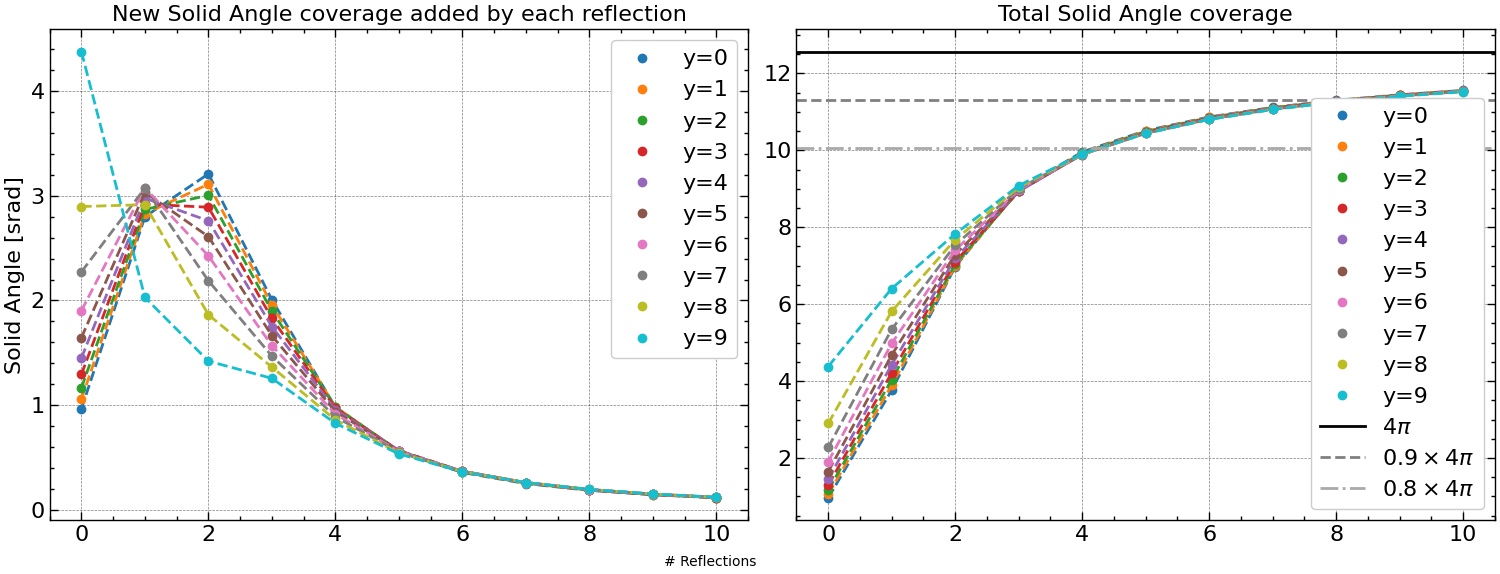

In [ ]:
    N = 10
    fig, ax = plt.subplots(ncols=2, figsize=(16,6))
    edep_idx=[(0,y,0) for y in range(nCells[1])]
    col=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
        '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
    for i, edep in enumerate(edep_idx):
        tot_sum = []
        tot_cum = []
        for x_i in range(nCells[0]):
            for z_i in range(nCells[2]):
                omegas = compute_angles(edep, (x_i, z_i), N)
                omegas = [[pair[0] for pair in sublist] for sublist in omegas]
                omega_sum = [np.sum(x) for x in omegas]
                omega_cum = list(accumulate(omega_sum))

                tot_sum.append(omega_sum)
                tot_cum.append(omega_cum)

        full_sum = [sum(values) for values in zip(*tot_sum)]
        full_cum = [sum(values) for values in zip(*tot_cum)]

        ax[0].plot(np.arange(N+1), full_sum, 'o',  color=col[i], label=f'y={edep[1]}')
        ax[0].plot(np.arange(N+1), full_sum, '--', color=col[i])

        ax[1].plot(np.arange(N+1), full_cum, 'o',  color=col[i], label=f'y={edep[1]}')
        ax[1].plot(np.arange(N+1), full_cum, '--', color=col[i])

    ax[0].set_title("New Solid Angle coverage added by each reflection")
    ax[1].set_title("Total Solid Angle coverage")
    ax[0].set_ylabel("Solid Angle [srad]")
    ax[1].axhline(4*np.pi, color='k', linestyle='-', label=r'$4\pi$')
    ax[1].axhline(0.9*4*np.pi, color='gray', linestyle='--', label=r'$0.9 \times 4\pi$')
    ax[1].axhline(0.8*4*np.pi, color='darkgray', linestyle='-.', label=r'$0.8 \times 4\pi$')

    fig.text(0.5, 0.04, '# Reflections', ha='center')
    plt.tight_layout(rect=[0.05, 0.05, 1, 1])
    ax[0].legend()
    ax[1].legend(loc='lower right')

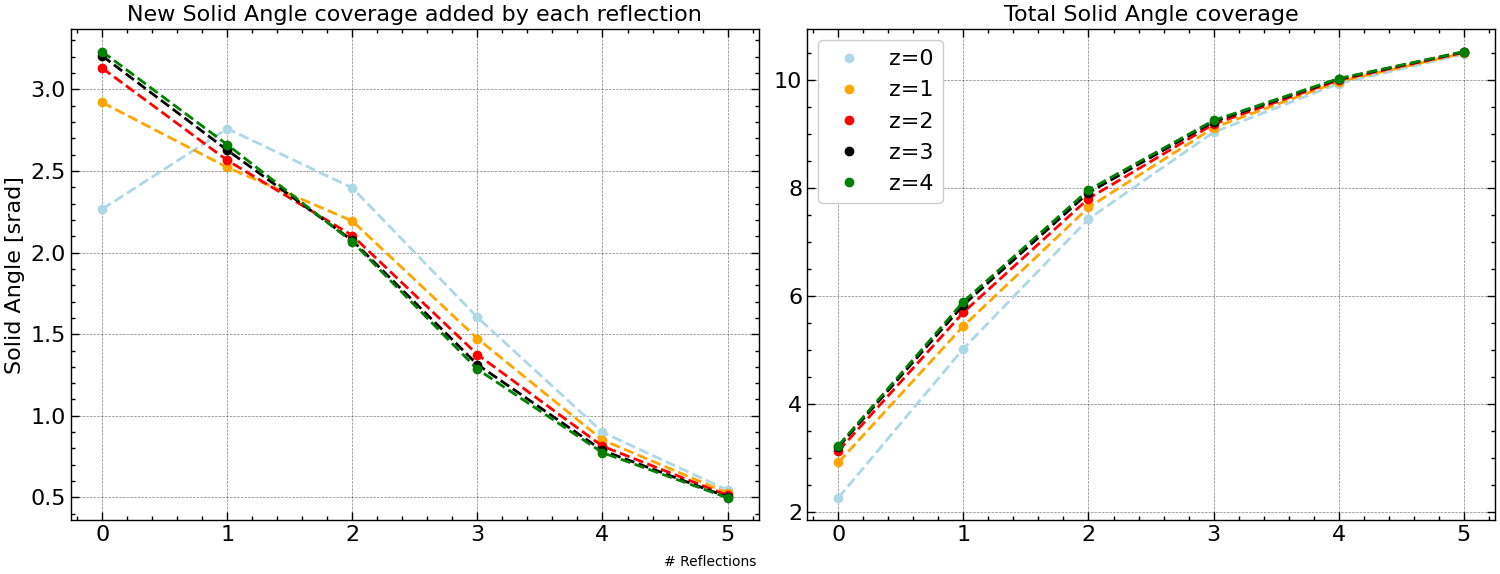

In [38]:
N = 5
fig, ax = plt.subplots(ncols=2, figsize=(16,6))
edep_idx=[(5,5,z) for z in [0,1,2,3,4]]
col=['lightblue', 'orange', 'red', 'black', 'green']
for i, edep in enumerate(edep_idx):
    tot_sum = []
    tot_cum = []
    for x_i in range(nCells[0]):
        for z_i in range(nCells[2]):
            omegas = compute_angles(edep, (x_i, z_i), N)
            omegas = [[pair[0] for pair in sublist] for sublist in omegas]
            omega_sum = [np.sum(x) for x in omegas]
            omega_cum = list(accumulate(omega_sum))

            tot_sum.append(omega_sum)
            tot_cum.append(omega_cum)

    full_sum = [sum(values) for values in zip(*tot_sum)]
    full_cum = [sum(values) for values in zip(*tot_cum)]

    ax[0].plot(np.arange(N+1), full_sum, 'o',  color=col[i], label=f'z={edep[2]}')
    ax[0].plot(np.arange(N+1), full_sum, '--', color=col[i])

    ax[1].plot(np.arange(N+1), full_cum, 'o',  color=col[i], label=f'z={edep[2]}')
    ax[1].plot(np.arange(N+1), full_cum, '--', color=col[i])

ax[0].set_title("New Solid Angle coverage added by each reflection")
ax[1].set_title("Total Solid Angle coverage")
ax[0].set_ylabel("Solid Angle [srad]")
fig.text(0.5, 0.04, '# Reflections', ha='center')
plt.tight_layout(rect=[0.05, 0.05, 1, 1])
ax[1].legend()

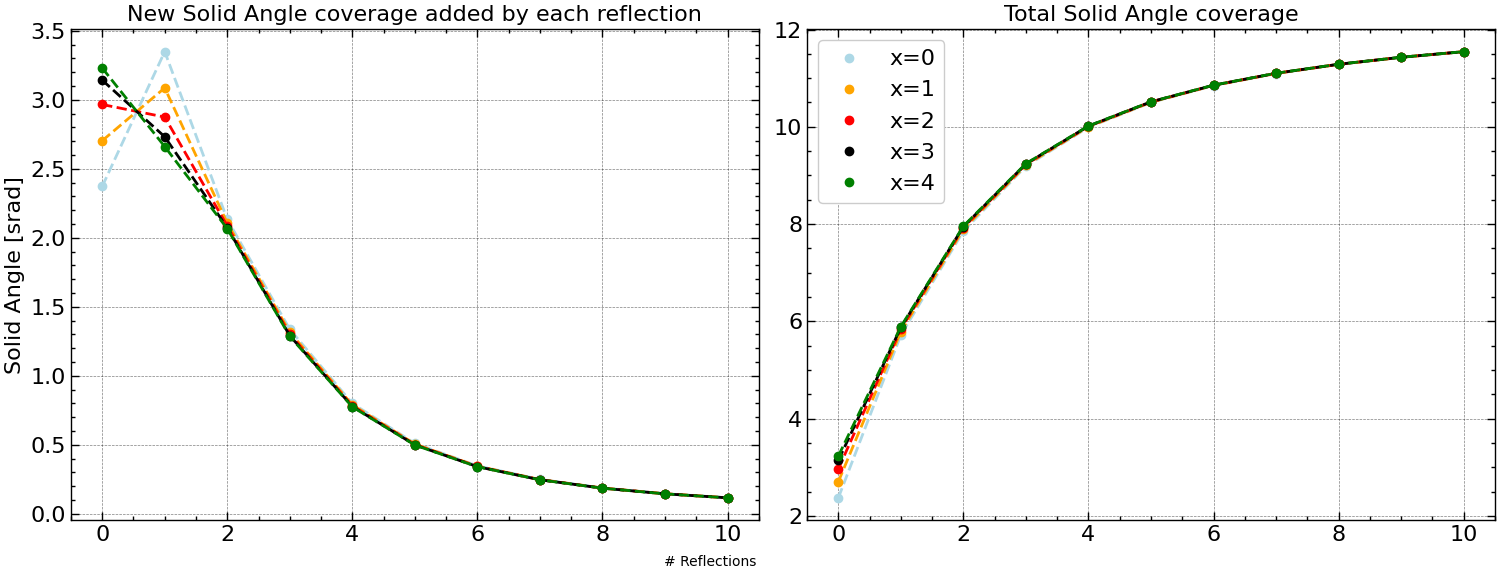

In [39]:
N = 10
fig, ax = plt.subplots(ncols=2, figsize=(16,6))
edep_idx=[(x,5,5) for x in [0,1,2,3,4]]
col=['lightblue', 'orange', 'red', 'black', 'green']
for i, edep in enumerate(edep_idx):
    tot_sum = []
    tot_cum = []
    for x_i in range(nCells[0]):
        for z_i in range(nCells[2]):
            omegas = compute_angles(edep, (x_i, z_i), N)
            omegas = [[pair[0] for pair in sublist] for sublist in omegas]
            omega_sum = [np.sum(x) for x in omegas]
            omega_cum = list(accumulate(omega_sum))

            tot_sum.append(omega_sum)
            tot_cum.append(omega_cum)

    full_sum = [sum(values) for values in zip(*tot_sum)]
    full_cum = [sum(values) for values in zip(*tot_cum)]

    ax[0].plot(np.arange(N+1), full_sum, 'o',  color=col[i], label=f'x={edep[0]}')
    ax[0].plot(np.arange(N+1), full_sum, '--', color=col[i])

    ax[1].plot(np.arange(N+1), full_cum, 'o',  color=col[i], label=f'x={edep[0]}')
    ax[1].plot(np.arange(N+1), full_cum, '--', color=col[i])

ax[0].set_title("New Solid Angle coverage added by each reflection")
ax[1].set_title("Total Solid Angle coverage")
ax[0].set_ylabel("Solid Angle [srad]")
fig.text(0.5, 0.04, '# Reflections', ha='center')
plt.tight_layout(rect=[0.05, 0.05, 1, 1])
ax[1].legend()

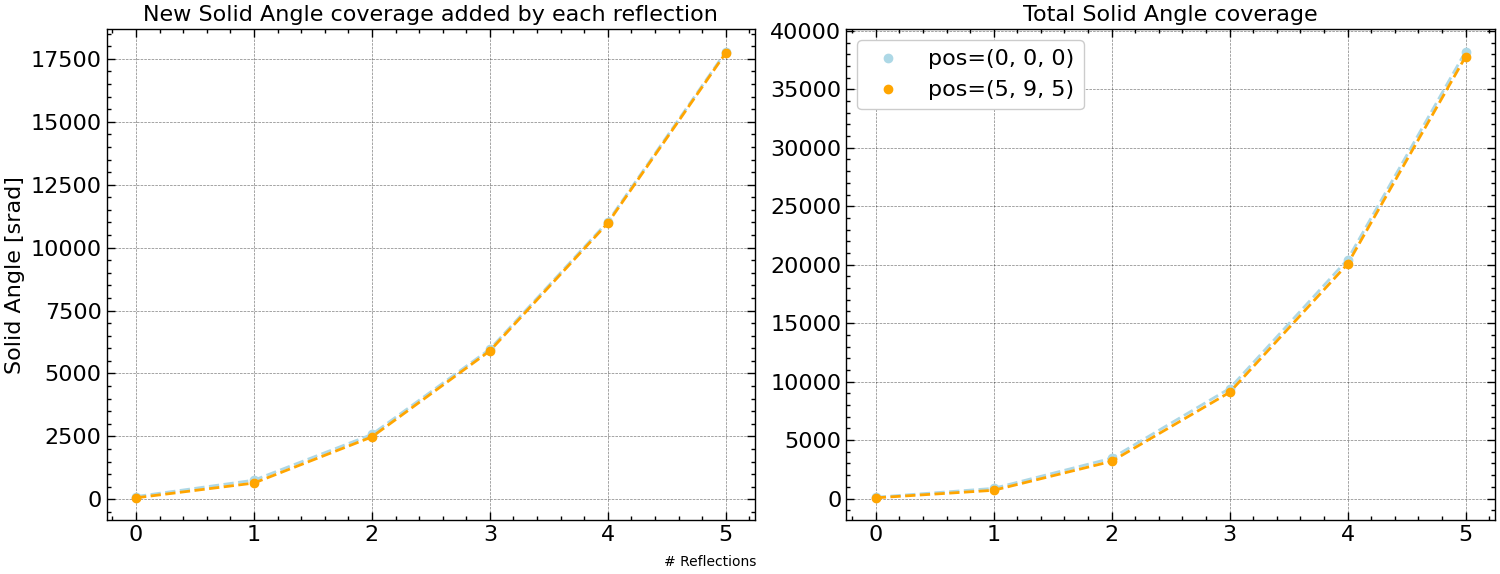

In [40]:
N = 5
fig, ax = plt.subplots(ncols=2, figsize=(16,6))
edep_idx=[(0,0,0), (5,9,5)]
col=['lightblue', 'orange', 'red', 'black', 'green']
for i, edep in enumerate(edep_idx):
    tot_sum = []
    tot_cum = []
    for x_i in range(nCells[0]):
        for z_i in range(nCells[2]):
            omegas = compute_angles(edep, (x_i, z_i), N)
            omega_sum = [np.sum(x) for x in omegas]
            omega_cum = list(accumulate(omega_sum))

            tot_sum.append(omega_sum)
            tot_cum.append(omega_cum)

    full_sum = [sum(values) for values in zip(*tot_sum)]
    full_cum = [sum(values) for values in zip(*tot_cum)]

    ax[0].plot(np.arange(N+1), full_sum, 'o',  color=col[i], label=f'pos={edep}')
    ax[0].plot(np.arange(N+1), full_sum, '--', color=col[i])

    ax[1].plot(np.arange(N+1), full_cum, 'o',  color=col[i], label=f'pos={edep}')
    ax[1].plot(np.arange(N+1), full_cum, '--', color=col[i])

ax[0].set_title("New Solid Angle coverage added by each reflection")
ax[1].set_title("Total Solid Angle coverage")
ax[0].set_ylabel("Solid Angle [srad]")
fig.text(0.5, 0.04, '# Reflections', ha='center')
plt.tight_layout(rect=[0.05, 0.05, 1, 1])
ax[1].legend()

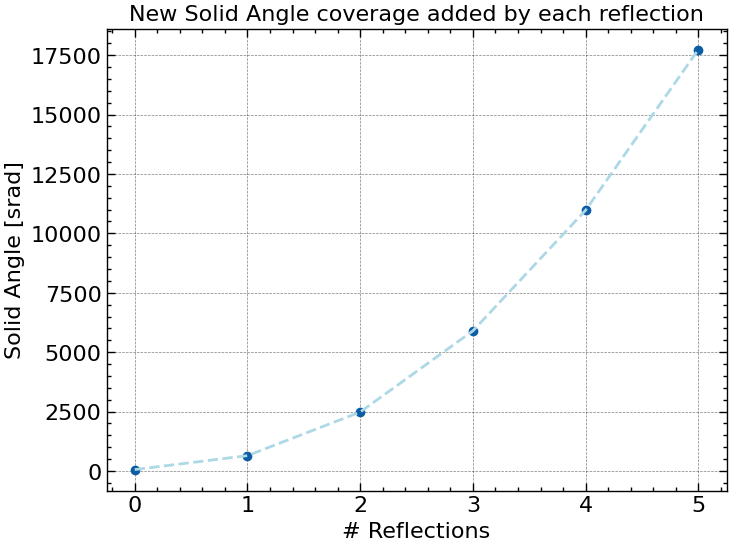

In [41]:
full_sum = [sum(values) for values in zip(*tot_sum)]
x = 6
plt.title("New Solid Angle coverage added by each reflection")
plt.ylabel("Solid Angle [srad]")
plt.xlabel("# Reflections")
plt.plot(np.arange(x), full_sum[:x], 'o')
plt.plot(np.arange(x), full_sum[:x], '--', color="lightblue")

In [42]:
a = [1,2,3]
b = [84,4,3]
c = list(zip(a,b))
c

[(1, 84), (2, 4), (3, 3)]

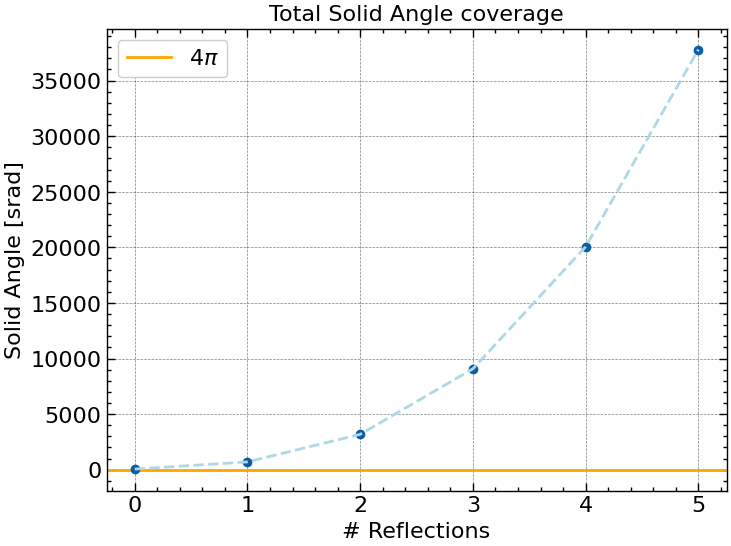

In [43]:
full_cum = [sum(values) for values in zip(*tot_cum)]
x = 6
plt.axhline(4*np.pi, label="$4\pi$", color='orange')
plt.title("Total Solid Angle coverage")
plt.ylabel("Solid Angle [srad]")
plt.xlabel("# Reflections")
plt.plot(np.arange(x), full_cum[:x], 'o')
plt.plot(np.arange(x), full_cum[:x], '--', color="lightblue")
plt.legend()

## Simulate Fake Event

In [44]:
import torch
a = torch.rand((100, 10, 10, 10, 10, 10))

In [45]:
a.nelement() * a.element_size()

40000000